# Part 1: EDA + Fraud Insights

In [1]:
import pandas as pd

df = pd.read_csv('/content/sample_data/fraud_analysis.csv', header=0)

df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [2]:
df.shape

(6362620, 11)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [ ]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [ ]:
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


In [ ]:
df['isFraud'].value_counts()

,count
isFraud,
0,6354407
1,8213


In [ ]:
df['isFraud'].value_counts(normalize=True) * 100

,proportion
isFraud,
0,99.870918
1,0.129082


In [ ]:
pd.crosstab(df['type'], df['isFraud'])

isFraud,0,1
type,,
CASH_IN,1399284,0
CASH_OUT,2233384,4116
DEBIT,41432,0
PAYMENT,2151495,0
TRANSFER,528812,4097


In [ ]:
fraud_rate = df.groupby('type')['isFraud'].mean() * 100

fraud_rate.sort_values(ascending=False)

,isFraud
type,
TRANSFER,0.768799
CASH_OUT,0.183955
CASH_IN,0.000000
DEBIT,0.000000
PAYMENT,0.000000


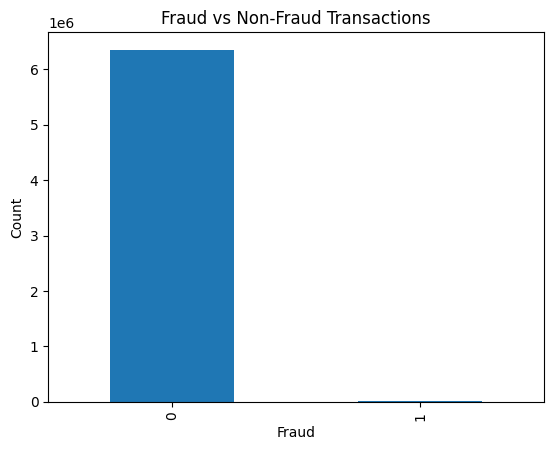

In [ ]:
import matplotlib.pyplot as plt

df['isFraud'].value_counts().plot(kind='bar')

plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Fraud")
plt.ylabel("Count")

plt.show()

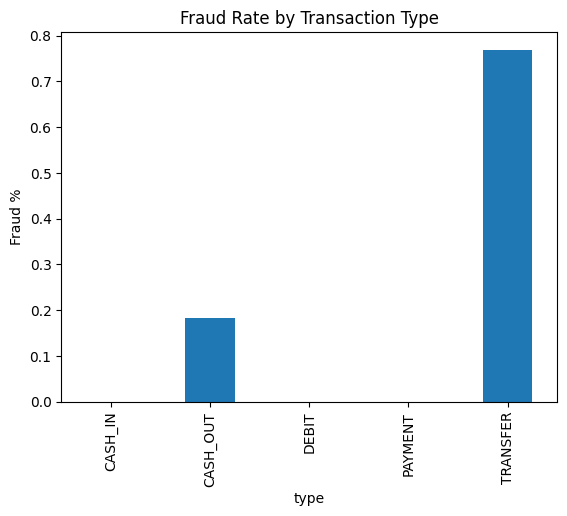

In [ ]:
fraud_rate = df.groupby('type')['isFraud'].mean() * 100

fraud_rate.plot(kind='bar')

plt.title("Fraud Rate by Transaction Type")
plt.ylabel("Fraud %")

plt.show()

# Part 2: Risk features + rules

**Compare Fraud vs Non-Fraud Transaction Amounts**

Understand whether fraud transactions tend to have:
*   larger amounts
*   unusual distributions
*   extreme outliers

In [ ]:
df.groupby('isFraud')['amount'].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,1.781970e+05,5.962370e+05,0.01,13368.395,74684.72,208364.76,92445516.64
1,8213.0,1.467967e+06,2.404253e+06,0.00,127091.330,441423.44,1517771.48,10000000.00


**Visualize Fraud Amount Distribution**
*   fraud amounts cluster in certain ranges (right-skewed)
*   there are large outliers
*   some frauds attempt to drain accounts completely

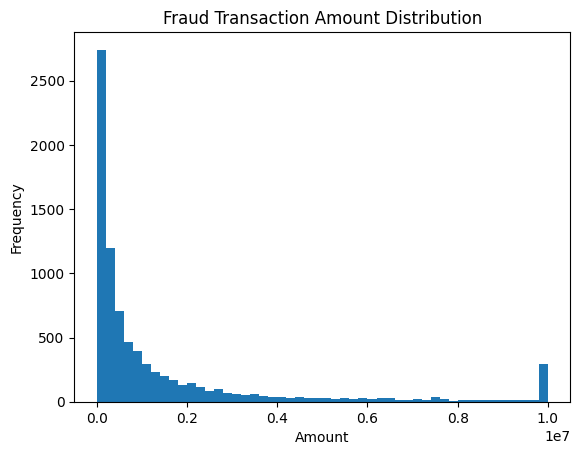

In [ ]:
import matplotlib.pyplot as plt

fraud = df[df['isFraud'] == 1]
non_fraud = df[df['isFraud'] == 0]

plt.hist(fraud['amount'], bins=50)
plt.title("Fraud Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")

plt.show()

**Analyze Account Draining Behavior**

Fraudsters often: empty the sender account and transfer all funds out

In [ ]:
fraud[['oldbalanceOrg', 'newbalanceOrig']].head()

,oldbalanceOrg,newbalanceOrig
2,181.0,0.0
3,181.0,0.0
251,2806.0,0.0
252,2806.0,0.0
680,20128.0,0.0


In [ ]:
df['account_drained'] = (
    (df['oldbalanceOrg'] > 0) &
    (df['newbalanceOrig'] == 0)
).astype(int)

In [ ]:
pd.crosstab(df['account_drained'], df['isFraud'], normalize='index') * 100

isFraud,0,1
account_drained,,
0,99.995849,0.004151
1,99.473096,0.526904


**Analyze Fraud by Time**

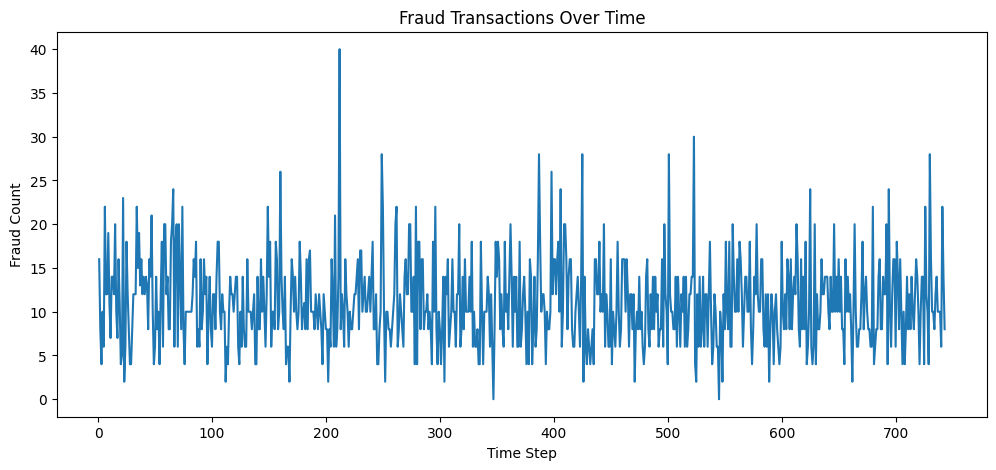

In [ ]:
fraud_by_step = df.groupby('step')['isFraud'].sum()

fraud_by_step.plot(figsize=(12,5))

plt.title("Fraud Transactions Over Time")
plt.xlabel("Time Step")
plt.ylabel("Fraud Count")

plt.show()

**Analyze High-Risk Transaction Types More Deeply**

In [ ]:
high_risk = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])]

high_risk.groupby('type')['isFraud'].mean() * 100

,isFraud
type,
CASH_OUT,0.183955
TRANSFER,0.768799


**Create Initial Risk Flags**

In [ ]:
df['large_amount_flag'] = (df['amount'] > 200000).astype(int)

In [ ]:
df['high_risk_type'] = (
    df['type'].isin(['TRANSFER', 'CASH_OUT'])
).astype(int)

**Create Simple Risk Score**

In [ ]:
df['risk_score'] = (
    df['large_amount_flag'] * 30 +
    df['high_risk_type'] * 40 +
    df['account_drained'] * 30
)

In [ ]:
def risk_category(score):
    if score >= 70:
        return 'High'
    elif score >= 40:
        return 'Medium'
    else:
        return 'Low'

df['risk_category'] = df['risk_score'].apply(risk_category)

It checks: “Within each risk group, what % is actually fraud?”

Why normalize='index' matters: It converts counts into row-wise percentages, so each row sums to 100%.

In [ ]:
pd.crosstab(
    df['risk_category'],
    df['isFraud'],
    normalize='index'
) * 100

isFraud,0,1
risk_category,,
High,99.539952,0.460048
Low,100.000000,0.000000
Medium,99.997276,0.002724


In [3]:
import pandas as pd

# Total Transactions
total_transactions = len(df)

# Fraud Transactions
fraud_transactions = df['isFraud'].sum()

# Fraud Rate (%)
fraud_rate = (fraud_transactions / total_transactions) * 100

# Fraud Amount (total money lost due to fraud)
fraud_amount = df.loc[df['isFraud'] == 1, 'amount'].sum()

# Total Transaction Amount
total_amount = df['amount'].sum()

# Fraud Loss % (fraud amount as % of total transaction value)
fraud_loss_pct = (fraud_amount / total_amount) * 100

# Print results
print("Total Transactions:", total_transactions)
print("Fraud Transactions:", fraud_transactions)
print("Fraud Rate (%):", round(fraud_rate, 4))
print("Fraud Amount:", round(fraud_amount, 2))
print("Fraud Loss (%):", round(fraud_loss_pct, 4))

Total Transactions: 6362620
Fraud Transactions: 8213
Fraud Rate (%): 0.1291
Fraud Amount: 12056415427.84
Fraud Loss (%): 1.0535
